# **Algorithm : CatBoost**

## **Project : E-Commerce Recommendation Engine**

### **Problem Statement:**

- Build recommendation systems using categorical customer data.

In [31]:
!pip install catboost

In [32]:
# Step No 1 : Import Required Libraries 
# import pandas for data manipulation
import pandas as pd 

# Import numpy for numerical operations 
import numpy as np

# Import matplotlib for visualization 
import matplotlib.pyplot as plt 

# Import seaborn for visualization
import seaborn as sns

# Import ML Libraries 
# Import train_test_split for splitting data
from sklearn.model_selection import train_test_split

# Import CatBoost classification model
from catboost import CatBoostClassifier

# Import Evaluation Metrics
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             confusion_matrix,
                             classification_report,
                             roc_auc_score,
                             roc_curve)

In [33]:
# Step No 2 : Load the e-commerce recommendation dataset 
df = pd.read_csv(
    "ecommerce_recommendation_engine_catboost.csv"
)

In [34]:
# Step No 3 : Data manipulation
# Display first 5 rows 
print("Dataset five rows : " , df.head())

# Display number of rows and columns 
print("Rows and Columns : " , df.shape)

# Display all column names 
print("Columns Names : " , df.columns)

# Display dataset information
print("Dataset Information is : ",df.info())

# Display statistical summary of numerical columns
print("Display Statistical summary : ", df.describe())

Dataset five rows :    Customer_ID Age_Group  Gender       City Customer_Segment Product_Category  \
0     C000001     26-35    Male       Pune          Regular      Electronics   
1     C000002     36-45  Female  Hyderabad          Premium           Beauty   
2     C000003     18-25  Female     Mumbai              New          Fashion   
3     C000004       56+  Female    Chennai          Regular           Beauty   
4     C000005       56+  Female     Jaipur          Premium           Sports   

  Product_Brand Device_Type Membership_Type Browsing_Category  \
0       Brand_C      Mobile           Basic       Electronics   
1       Brand_C      Mobile        Platinum             Books   
2       Brand_E      Mobile           Basic       Electronics   
3       Brand_A      Mobile           Basic           Fashion   
4       Brand_C      Mobile        Platinum            Sports   

  Previous_Purchase_Category Price_Range Discount_Available  Review_Rating  \
0                    Fashion 

In [35]:
# Step No 4 : Data Cleaning and Handle Missing values 
# Check Missing Values 
print("Check Missing Values is : ", df.isnull().sum())

# Handle Missing Values 
df["Previous_Purchase_Category"] = df[
    "Previous_Purchase_Category"
].fillna("Unknown")

# Check missing values after treatment 
print(df.isnull().sum())

# Check total missing values after treatment
print(
    "Total Missing Values After Treatment"
)

print("Duplicate Rows:",df.duplicated().sum())

# Remove duplicate rows if duplicates are present 
df = df.drop_duplicates()

# Display shape after duplicate removal
print("Shape After Duplicate Removal: ",df.shape)

Check Missing Values is :  Customer_ID                      0
Age_Group                        0
Gender                           0
City                             0
Customer_Segment                 0
Product_Category                 0
Product_Brand                    0
Device_Type                      0
Membership_Type                  0
Browsing_Category                0
Previous_Purchase_Category    6099
Price_Range                      0
Discount_Available               0
Review_Rating                    0
Browsing_Time_Min                0
Purchase_Frequency               0
Recommended                      0
dtype: int64
Customer_ID                   0
Age_Group                     0
Gender                        0
City                          0
Customer_Segment              0
Product_Category              0
Product_Brand                 0
Device_Type                   0
Membership_Type               0
Browsing_Category             0
Previous_Purchase_Category    0
Price_Range  

In [36]:
# Step No 5 : Check Target Variable 
# Count each recommendation class 
print(df["Recommended"].value_counts())
# Target meaning
# 0 = Product is not recommended
# 1 = Product is recommended

Recommended
1    36820
0    13180
Name: count, dtype: int64


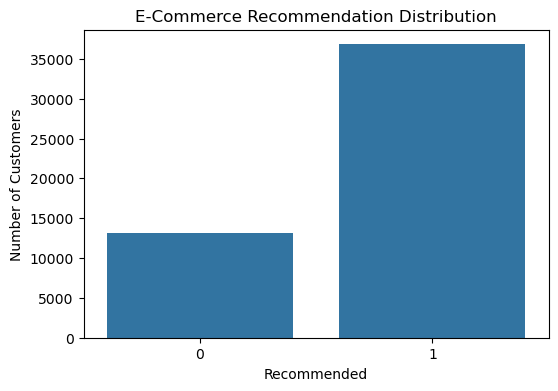

In [37]:
# Step No 6 : Target Visualization
# Set figure size 
plt.figure(figsize=(6,4))

# Create Count Plot 
sns.countplot(
    x = "Recommended",
    data=df
)
# Add title 
plt.title("E-Commerce Recommendation Distribution")

# Add X-axis label
plt.xlabel("Recommended")

# Add Y-axis label
plt.ylabel("Number of Customers")

# Display graph
plt.show()

In [38]:
# Step No 7 : Recommendation Percentage
# Calculate recommendation percentage
recommendation_percentage = (
    df["Recommended"].value_counts(normalize=True) * 100
)

# Display recommendation percentage
print(
    recommendation_percentage
)

Recommended
1    73.64
0    26.36
Name: proportion, dtype: float64


In [39]:
# Step No 8 : Correlation Analysis 
# Select numerical columns
numeric_data = df.select_dtypes(
    include=["int64" , "float64"]
)

# Calculate correlation matrix 
correlation = numeric_data.corr()

# Display correlation matrix 
print(correlation)

                    Review_Rating  Browsing_Time_Min  Purchase_Frequency  \
Review_Rating            1.000000           0.002438            0.004221   
Browsing_Time_Min        0.002438           1.000000           -0.003035   
Purchase_Frequency       0.004221          -0.003035            1.000000   
Recommended              0.035640           0.228775            0.113978   

                    Recommended  
Review_Rating          0.035640  
Browsing_Time_Min      0.228775  
Purchase_Frequency     0.113978  
Recommended            1.000000  


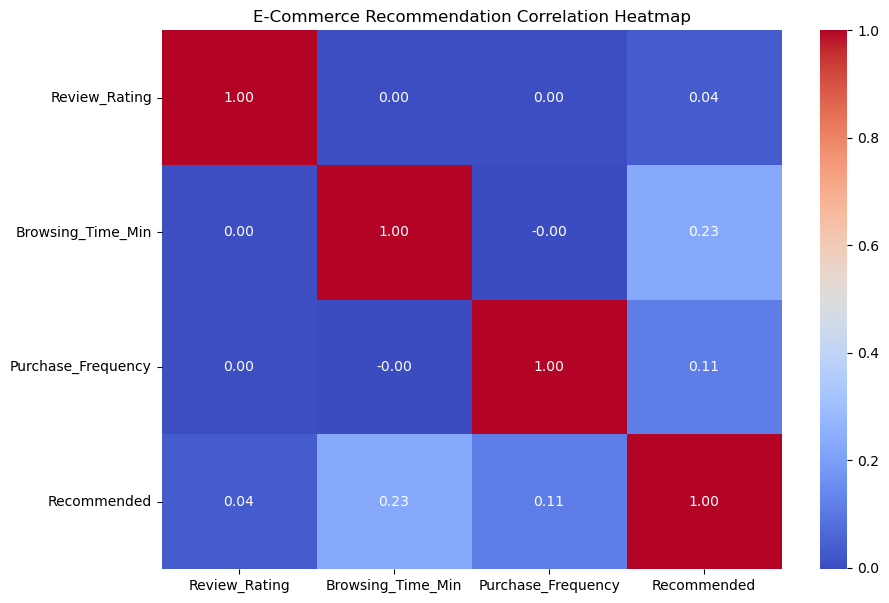

In [40]:
# Step No 9 : Correlation Heatmap
# Set figure size 
plt.figure(figsize=(10,7))

# Create correlation heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
# Add title 
plt.title("E-Commerce Recommendation Correlation Heatmap")

# Display graph
plt.show()

In [41]:
# Step No 10 : Define Features and Target 
# Remove Customer_ID because it is only an identifier
X = df.drop(
    columns=[
        "Customer_ID",
        "Recommended"
    ]
)

# Create target variable 
y = df["Recommended"]

# Display feature names 
print("Features:")
print(X.columns)

# Display Target Variable 
print("\nTarget : ")
print(y.name)

Features:
Index(['Age_Group', 'Gender', 'City', 'Customer_Segment', 'Product_Category',
       'Product_Brand', 'Device_Type', 'Membership_Type', 'Browsing_Category',
       'Previous_Purchase_Category', 'Price_Range', 'Discount_Available',
       'Review_Rating', 'Browsing_Time_Min', 'Purchase_Frequency'],
      dtype='object')

Target : 
Recommended


In [42]:
# Step No 11 : Feature Engineering 
# Create browsing engagement score 
# Combines browsing time and purchase frequency
X["Browsing_Engagement"] = (
    X["Browsing_Time_Min"] * 
    (X["Purchase_Frequency"] + 1)
)

# Create review engagement score 
# Combines review rating and browsing time 
X["Review_Engagement"] = (
    X["Review_Rating"] * 
    X["Browsing_Time_Min"]
)

# Create browsing to purchase ratio
# Shows browsing activity compared with purchase frequency

X["Browsing_Purchase_Ratio"] = (
    X["Browsing_Time_Min"] /
    (X["Purchase_Frequency"] + 1)
)

# Create category match feature 
# Checks whether current browsing category
# matches previous purchase category
X["Category_Match"] = (
    X["Browsing_Category"] ==
    X["Previous_Purchase_Category"]
).astype(int)

# Create discount interest feature 
# Converts discount availability into numerical value 
X["Discount_Interest"] = (
    X["Discount_Available"] == "Yes"
).astype(int)

# Display engineered features
print(X.head())

  Age_Group  Gender       City Customer_Segment Product_Category  \
0     26-35    Male       Pune          Regular      Electronics   
1     36-45  Female  Hyderabad          Premium           Beauty   
2     18-25  Female     Mumbai              New          Fashion   
3       56+  Female    Chennai          Regular           Beauty   
4       56+  Female     Jaipur          Premium           Sports   

  Product_Brand Device_Type Membership_Type Browsing_Category  \
0       Brand_C      Mobile           Basic       Electronics   
1       Brand_C      Mobile        Platinum             Books   
2       Brand_E      Mobile           Basic       Electronics   
3       Brand_A      Mobile           Basic           Fashion   
4       Brand_C      Mobile        Platinum            Sports   

  Previous_Purchase_Category Price_Range Discount_Available  Review_Rating  \
0                    Fashion      Medium                Yes            4.7   
1                     Beauty      Medium    

In [43]:
# Step No 12 : Check Features After Feature Engineering

# Display all feature names 
print("Features After Feature Engineering : ") 

# Display feature names 
print(X.columns)

# Display feature shape 
print(
    "X Shape : ",
    X.shape
)

Features After Feature Engineering : 
Index(['Age_Group', 'Gender', 'City', 'Customer_Segment', 'Product_Category',
       'Product_Brand', 'Device_Type', 'Membership_Type', 'Browsing_Category',
       'Previous_Purchase_Category', 'Price_Range', 'Discount_Available',
       'Review_Rating', 'Browsing_Time_Min', 'Purchase_Frequency',
       'Browsing_Engagement', 'Review_Engagement', 'Browsing_Purchase_Ratio',
       'Category_Match', 'Discount_Interest'],
      dtype='object')
X Shape :  (50000, 20)


In [44]:
# Step No 13 : Prepare Categorical Features
# Identify categorical columns 
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Convert categorical columns into string format 
for column in categorical_features:
    
    # Convert values to string 
    X[column] = X[column].astype(str)
    
# Display categorical features 
print("Categorical Features : ")

print(categorical_features)

Categorical Features : 
['Age_Group', 'Gender', 'City', 'Customer_Segment', 'Product_Category', 'Product_Brand', 'Device_Type', 'Membership_Type', 'Browsing_Category', 'Previous_Purchase_Category', 'Price_Range', 'Discount_Available']


In [45]:
# Step No 14 : Check X and y Shape 
# Display feature shape 
print(
    "X Shape : ",
    X.shape)

# Display target shape 
print("y Shape : ",y.shape)


X Shape :  (50000, 20)
y Shape :  (50000,)


In [46]:
# Step No 15 : Train - Test Split 
# Split data into training and testing sets 
X_train , X_test , y_train , y_test = train_test_split(
    # Input features
    X,
    # Target Variable 
    y,
    # Use 20% data for testing 
    test_size = 0.20,
    # Set random state
    random_state=42,
    # Maintain target class proportion
    stratify=y
)

# Check Train-Test Data 
# Display training feature shape 
print(
    "X_train : ",
    X_train.shape
)

# Display testing feature shape 
print(
    "X_test : ",
    X_test .shape
)

# Display training target shape 
print("y_train : " , y_train.shape)

# Display testing target shape
print("y_test : " , y_test.shape)

X_train :  (40000, 20)
X_test :  (10000, 20)
y_train :  (40000,)
y_test :  (10000,)


In [47]:
# Step No 16 : Create CatBoost Model 
# Create CatBoost classification model 
catboost_model = CatBoostClassifier(
    
    # Number of boosting iterations 
    iterations = 300,
    
    # Learning rate 
    learning_rate = 0.05,
    
    # Maximum tree depth
    depth = 6 , 
    
    # Loss function for binary classification
    loss_function = "Logloss",
    
    # Evaluation metric
    eval_metric = "AUC",
    
    # Random seed 
    random_seed = 42,
    
    # Display training progress 
    verbose = 50
)

In [48]:
# Step No 17 : Train CatBoost Model
# Train the CatBoost Model 
catboost_model.fit(
    
    # Training features 
    X_train,
    
    # Training targer 
    y_train,
    
    # Specify categorical features 
    cat_features = categorical_features,
    
    # Use test data for evaluation
    eval_set = (X_test , y_test),
    
    # Stop training if validation performance stops improving 
    early_stopping_rounds = 50
)

0:	test: 0.6595665	best: 0.6595665 (0)	total: 56ms	remaining: 16.8s
50:	test: 0.6890024	best: 0.6890024 (50)	total: 2.58s	remaining: 12.6s
100:	test: 0.6909534	best: 0.6909534 (100)	total: 4.96s	remaining: 9.78s
150:	test: 0.6919518	best: 0.6919692 (145)	total: 7.21s	remaining: 7.12s
200:	test: 0.6922569	best: 0.6922746 (199)	total: 9.67s	remaining: 4.76s
250:	test: 0.6921889	best: 0.6923553 (206)	total: 12.2s	remaining: 2.39s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6923553167
bestIteration = 206

Shrink model to first 207 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=50)

In [49]:
# Step No 18 : Prediction
# Make predictions on test data 
y_pred = catboost_model.predict(
    X_test
)
# Convert predictions into 1D integer array
y_pred = y_pred.astype(int).ravel()

# Display first 20 predictions 
print(y_pred[:20])

[1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1]


In [50]:
# Step No 19 : Prediction Probability 
# Calculate recommendation probability
y_pred_proba = catboost_model.predict_proba(
    X_test
)[:,1]

# Display first 10 probabilities 
print(y_pred_proba[:10])

[0.71275002 0.58870581 0.61655372 0.63578683 0.84838175 0.75494906
 0.57293279 0.45323157 0.59527496 0.74643547]


In [51]:
# Step No 20 : Evaluation Metrics 
# Calculate Accuracy 
accuracy = accuracy_score(
    y_test,
    y_pred
)
# Display accuracy 
print("Accuracy : ",accuracy)

# Display accuracy percentage 
print("Accuracy Percentage : " , accuracy * 100)

# Calculate Precision
precision = precision_score(
    y_test,
    y_pred
)
# Display precision
print("Precision : ", precision)

# Calculate recall
recall = recall_score(
    y_test,
    y_pred
)
# Display recall
print("Recall : ", recall)

# Calculate F1 Score 
f1 = f1_score(
    y_test , 
    y_pred
)
# Display F1 score 
print("F1 Score : ",f1)

# Calculate ROC-AUC Score 
roc_auc = roc_auc_score(
    y_test ,
    y_pred_proba
)

# Display ROC-AUC score 
print("ROC-AUC Score : ",roc_auc)

# Display Model Performance 
print("======== CATBOOST MODEL PERFORMANCE =========")

# Display accuracy 
print("Accuracy : ",round(accuracy,4))

# Display precision
print("Precision : ", round(precision , 4))

# Display recall
print("Recall : " , round(recall , 4 ))

# Display F1 Score 
print("F1 Score : ",round(f1 , 4))

# Display ROC-AUC
print("ROC-AUC : " , round(roc_auc , 4))

# Generate Classification Report 
report = classification_report(
    y_test , 
    y_pred
)

# Display classification report 
print(report)

# Confusion Matrix 
# Calculate Confusion Matrix 
cm = confusion_matrix(y_test,y_pred)

# Display Confusion Matrix 
print(cm)

Accuracy :  0.7401
Accuracy Percentage :  74.00999999999999
Precision :  0.7499737698037982
Recall :  0.9706681151548072
F1 Score :  0.846167505179047
ROC-AUC Score :  0.6923553167235263
======== CATBOOST MODEL PERFORMANCE =========
Accuracy :  0.7401
Precision :  0.75
Recall :  0.9707
F1 Score :  0.8462
ROC-AUC :  0.6924
              precision    recall  f1-score   support

           0       0.54      0.10      0.16      2636
           1       0.75      0.97      0.85      7364

    accuracy                           0.74     10000
   macro avg       0.64      0.53      0.50     10000
weighted avg       0.69      0.74      0.67     10000

[[ 253 2383]
 [ 216 7148]]


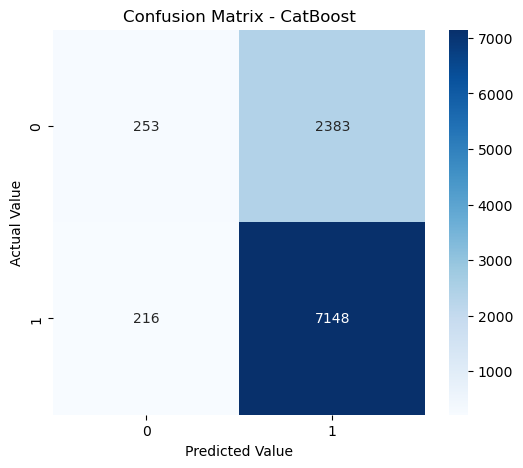

In [52]:
# Step No 21 : Confusion Matrix Visualization
# Set figure size 
plt.figure(figsize=(6 , 5))

# Create Confusion matrix heatmap 
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Add title 
plt.title("Confusion Matrix - CatBoost")

# Add X-axis label 
plt.xlabel("Predicted Value")

# Add Y-axis label
plt.ylabel("Actual Value")

# Display graph
plt.show()

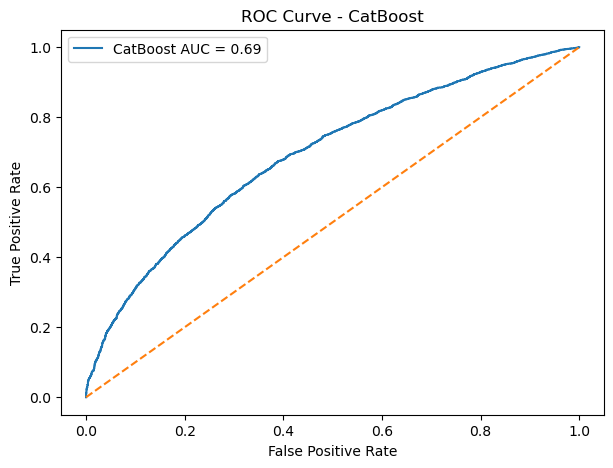

In [53]:
# Step No 22 : ROC Curve 
# Calculate False Positive Rate and True Positive Rate 
fpr , tpr , thresholds = roc_curve(
    y_test,
    y_pred_proba
)

# Set figure size 
plt.figure(figsize=(7,5))

# Plot ROC curve 
plt.plot(
    fpr,
    tpr,
    label = f"CatBoost AUC = {roc_auc:.2f}"
)

# Plot random classifier line 
plt.plot(
    [0 , 1],
    [0 , 1],
    linestyle = "--"
)

# Add X-axis label 
plt.xlabel("False Positive Rate")
# Add Y-axis label 
plt.ylabel("True Positive Rate")

# Add title 
plt.title("ROC Curve - CatBoost")

# Display legend 
plt.legend()

# Display graph
plt.show()

In [54]:
# Step No 23 :  Get feature importance values
importance_values = (
    catboost_model.get_feature_importance()
)

# Create feature importance DataFrame
feature_importance = pd.DataFrame({

    # Store feature names
    "Feature": X.columns,

    # Store importance values
    "Importance": importance_values
})

# Sort features by importance 
feature_importance = feature_importance.sort_values(
    by = "Importance",
    ascending=False
)

# Display feature importance e
print(feature_importance)

                       Feature  Importance
15         Browsing_Engagement   23.423095
13           Browsing_Time_Min   16.884764
3             Customer_Segment   12.318502
7              Membership_Type    9.424156
16           Review_Engagement    6.102893
14          Purchase_Frequency    5.775097
12               Review_Rating    4.098436
17     Browsing_Purchase_Ratio    3.558309
6                  Device_Type    2.875964
4             Product_Category    2.598469
19           Discount_Interest    2.209522
11          Discount_Available    2.008960
9   Previous_Purchase_Category    1.846495
8            Browsing_Category    1.637748
5                Product_Brand    1.050326
2                         City    1.004240
0                    Age_Group    0.978470
10                 Price_Range    0.951762
1                       Gender    0.755771
18              Category_Match    0.497022


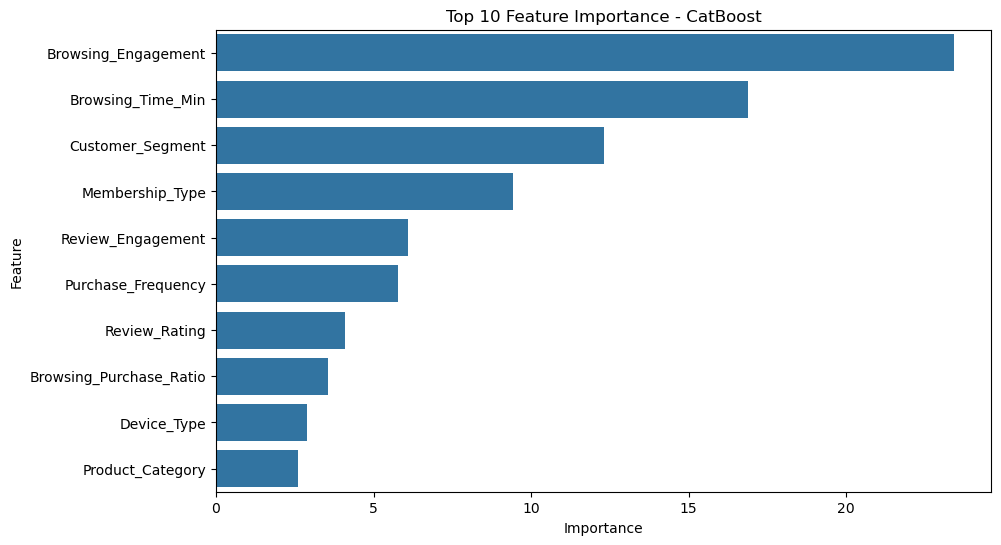

In [55]:
# Step No 24 : Feature Importance Visualization
# Set figure size 
plt.figure(figsize=(10 , 6))

# Plot top 10 important features
sns.barplot(
    x = "Importance",
    y = "Feature",
    data = feature_importance.head(10)
)

# Add title 
plt.title("Top 10 Feature Importance - CatBoost")

# Display graph 
plt.show()

In [56]:
# Step No 25 : Top 5 Features 
# Display heading 
print("Top 5 Important Features : ")

# Display top 5 features 
print(feature_importance.head(5))

Top 5 Important Features : 
                Feature  Importance
15  Browsing_Engagement   23.423095
13    Browsing_Time_Min   16.884764
3      Customer_Segment   12.318502
7       Membership_Type    9.424156
16    Review_Engagement    6.102893


In [57]:
# Step No 26 : User Input Prediction

# Create data for a new customer 
new_customer = pd.DataFrame({
    # Customer age group 
    "Age_Group": ["26-35"],
    # Customer gender
    "Gender":["Male"],
    # Customer city
    "City": ["Pune"],
    # Customer segment
    "Customer_Segment": ["Premium"],
    # Product category
    "Product_Category": ["Electronics"],
    # Product brand
    "Product_Brand":["Brand_C"],
    # Device type 
    "Device_Type": ["Mobile"],
    # Membership type
    "Membership_Type": ["Gold"],
    # Current browsing category
    "Browsing_Category": ["Electronics"],
    # Previous Purchase Category
    "Previous_Purchase_Category": ["Fashion"],
    
    # Price Range
    "Price_Range": ["Medium"],
    # Discount availability
    "Discount_Available": ["Yes"],
    # Review Rating 
    "Review_Rating": [4.5],
    # Browsing time in minutes
    "Browsing_Time_Min": [25.5],
    # Purchase frequency
    "Purchase_Frequency": [4]
})

# Display new customer data 
print(new_customer)

  Age_Group Gender  City Customer_Segment Product_Category Product_Brand  \
0     26-35   Male  Pune          Premium      Electronics       Brand_C   

  Device_Type Membership_Type Browsing_Category Previous_Purchase_Category  \
0      Mobile            Gold       Electronics                    Fashion   

  Price_Range Discount_Available  Review_Rating  Browsing_Time_Min  \
0      Medium                Yes            4.5               25.5   

   Purchase_Frequency  
0                   4  


In [58]:
# Step No 27 : Apply Same Feature Engineering
# Create browsing engagement score 
new_customer["Browsing_Engagement"] = (
    new_customer["Browsing_Time_Min"] * 
    (new_customer["Purchase_Frequency"] + 1)
)

# Create review engagement score 
new_customer["Review_Engagement"] = (
    new_customer["Review_Rating"] * 
    new_customer["Browsing_Time_Min"]
)

# Create browsing-to-purchase ratio
new_customer["Browsing_Purchase_Ratio"] = (
    new_customer["Browsing_Time_Min"] / 
    (new_customer["Purchase_Frequency"] + 1)
)

# Create category match feature 
new_customer["Category_Match"] = (
    new_customer["Browsing_Category"] ==
    new_customer["Previous_Purchase_Category"]
).astype(int)

# Create discount interest feature 
new_customer["Discount_Interest"] = (
    new_customer["Discount_Available"] == "Yes"
).astype(int)

# Display engineered customer data 
print(new_customer)

  Age_Group Gender  City Customer_Segment Product_Category Product_Brand  \
0     26-35   Male  Pune          Premium      Electronics       Brand_C   

  Device_Type Membership_Type Browsing_Category Previous_Purchase_Category  \
0      Mobile            Gold       Electronics                    Fashion   

  Price_Range Discount_Available  Review_Rating  Browsing_Time_Min  \
0      Medium                Yes            4.5               25.5   

   Purchase_Frequency  Browsing_Engagement  Review_Engagement  \
0                   4                127.5             114.75   

   Browsing_Purchase_Ratio  Category_Match  Discount_Interest  
0                      5.1               0                  1  


In [59]:
# Step No 28 : Prepare New Customer Data
# Convert Categorical columns into string format
for column in categorical_features:
    
    # Convert values to string 
    new_customer[column] = (
        new_customer[column].astype(str)
    )
# Arrange columns exactly like training data 
new_customer = new_customer.reindex(
    columns=X.columns
)

# Display final input data 
print(new_customer)

  Age_Group Gender  City Customer_Segment Product_Category Product_Brand  \
0     26-35   Male  Pune          Premium      Electronics       Brand_C   

  Device_Type Membership_Type Browsing_Category Previous_Purchase_Category  \
0      Mobile            Gold       Electronics                    Fashion   

  Price_Range Discount_Available  Review_Rating  Browsing_Time_Min  \
0      Medium                Yes            4.5               25.5   

   Purchase_Frequency  Browsing_Engagement  Review_Engagement  \
0                   4                127.5             114.75   

   Browsing_Purchase_Ratio  Category_Match  Discount_Interest  
0                      5.1               0                  1  


In [60]:
# Step No 29 : User Input Prediction
# Predict whether the product should be recommended 
new_prediction = catboost_model.predict(
    new_customer
)

# Calculate recommendation probability
new_probability = catboost_model.predict_proba(
    new_customer
)[0][1]

# Convert prediction into integer
new_prediction = int(
    new_prediction[0]
)

# Check prediction result
if new_prediction == 1:
    # Display recommendation result 
    print(
        "Product is RECOMMENDED for this customer ."
    )
else:
    # Display non-recommendation result 
    print(
        "Product is NOT RECOMMENDED for this customer ."
    )
# Display recommendation probability
print(
    "Recommendation Probability : ",
    round(new_probability * 100 , 2),
    "%"
)

Product is RECOMMENDED for this customer .
Recommendation Probability :  91.73 %
